Parte 1: Ingestión y Exploración

[04/07/26 15:38:46] INFO     Loading data from envios_raw (CSVDataset)...                      ]8;id=332795;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=679802;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

                    INFO     Loading data from incidencias_raw (CSVDataset)...                 ]8;id=684741;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=944556;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

                    INFO     Loading data from rutas_raw (CSVDataset)...                       ]8;id=819792;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=28508;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

                    INFO     Loading data from vehiculos_raw (CSVDataset)...                   ]8;id=671340;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=180674;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\


=== EXPLORACIÓN: envios_raw ===
Dimensiones: (1030, 9)
Nulos totales: 452
Duplicados: 30


...

------------------------------

=== EXPLORACIÓN: rutas_raw ===
Dimensiones: (82, 7)
Nulos totales: 28
Duplicados: 2


,id_ruta,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total
0,1.0,La Florida,Pucón,420.3,6.3,Camino Rural,13931.0
1,2.0,NaN,Castro,507.2,19.5,Camino Rural,12065.0
2,3.0,Rancagua,Rengo,679.6,18.4,Urbana,2447.0


------------------------------

=== EXPLORACIÓN: vehiculos_raw ===
Dimensiones: (61, 8)
Nulos totales: 27
Duplicados: 1


,id_vehiculo,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos
0,1.0,URLR-78,Camioneta,20000.0,49.2,2018.0,Operativo,267419.0
1,2.0,DPYA-28,Furgón,5000.0,38.7,2019.0,Operativo,179180.0
2,3.0,MAXQ-41,Camión,10000.0,69.4,2012.0,En mantención,478395.0


------------------------------
Análisis de tipos detectados en Envios:
id_envio         float64
fecha_envio          str
id_ruta          float64
id_vehiculo      float64
peso_kg              str
volumen_m3       float64
tipo_carga           str
estado               str
fecha_entrega        str
dtype: object


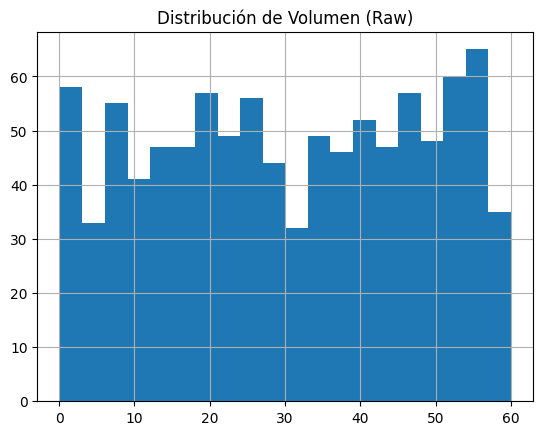

In [2]:
#Configurar
import pandas as pd
import matplotlib.pyplot as plt

#Carga de datos
datasets = ["envios_raw", "incidencias_raw", "rutas_raw", "vehiculos_raw"]
dfs = {name: catalog.load(name) for name in datasets}

#Diagnóstico Automatizado
def generar_diagnostico(df, nombre):
    print(f"\n=== EXPLORACIÓN: {nombre} ===")
    print(f"Dimensiones: {df.shape}")
    print(f"Nulos totales: {df.isnull().sum().sum()}")
    print(f"Duplicados: {df.duplicated().sum()}")
    display(df.head(3))
    print("-" * 30)

for name, df in dfs.items():
    generar_diagnostico(df, name)

# Aquí "descubrimos" que peso_kg e id_envio tienen problemas
print("Análisis de tipos detectados en Envios:")
print(dfs['envios_raw'].dtypes)

# Visualización rápida de una variable numérica
dfs['envios_raw']['volumen_m3'].hist(bins=20)
plt.title("Distribución de Volumen (Raw)")
plt.show()

Parte 2: Limpieza y Tratamiento

In [4]:
#Setup
import numpy as np

df_envios = catalog.load("envios_raw")

#Prototipo de Limpieza de Outliers ---
#Usaremos el Rango Intercuartílico (IQR)
def detectar_limites_iqr(data, columna):
    q1 = data[columna].quantile(0.25)
    q3 = data[columna].quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

inf, sup = detectar_limites_iqr(df_envios, 'volumen_m3')
print(f"Límites calculados para Volumen: [{inf:.2f}, {sup:.2f}]")

#Definición del Prototipo del Nodo
def cleaning_prototype(df):
    df_c = df.copy()
    # 1. IDs a entero/string (evitar el .0)
    df_c['id_envio'] = pd.to_numeric(df_c['id_envio'], errors='coerce').fillna(0).astype(int)
    # 2. Fechas
    df_c['fecha_envio'] = pd.to_datetime(df_c['fecha_envio'], errors='coerce')
    # 3. Strings
    df_c['tipo_carga'] = df_c['tipo_carga'].str.lower().str.strip()
    return df_c

#Verificación de Resultados
df_clean = cleaning_prototype(df_envios)
print("Tipos finales en el prototipo:")
print(df_clean.dtypes.head())

[04/07/26 15:39:41] INFO     Loading data from envios_raw (CSVDataset)...                      ]8;id=204030;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=531937;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

Límites calculados para Volumen: [-29.25, 90.98]
Tipos finales en el prototipo:
id_envio                int64
fecha_envio    datetime64[us]
id_ruta               float64
id_vehiculo           float64
peso_kg                   str
dtype: object


Pipeline 3: Tranformación e integración

In [6]:
#Carga de capas intermedias
envios = catalog.load("envios_inter")
rutas = catalog.load("rutas_inter")
vehiculos = catalog.load("vehiculos_inter")
incidencias = catalog.load("incidencias_inter")

#Prototipo de Agregación de Incidencias
# Probamos el groupby antes de unirlo todo
resumen_inc = incidencias.groupby("id_envio").agg({
    "costo_impacto": "sum",
    "id_incidencia": "count"
}).rename(columns={"costo_impacto": "total_costo_inc", "id_incidencia": "n_incidencias"}).reset_index()

#CELDA 3: El Master Join
master = envios.merge(rutas, on="id_ruta", how="left") \
               .merge(vehiculos, on="id_vehiculo", how="left") \
               .merge(resumen_inc, on="id_envio", how="left")

#Ingeniería de Variables
# Feature: Eficiencia de peso
master['eficiencia_peso'] = master['peso_kg'] / master['capacidad_kg']

# Feature: Tiempo de entrega en días
master['dias_entrega'] = (master['fecha_entrega'] - master['fecha_envio']).dt.days

#Preprocesamiento
from sklearn.preprocessing import StandardScaler

master_prep = pd.get_dummies(master, columns=["tipo_carga", "tipo_via"], drop_first=True)

# Estandarización
scaler = StandardScaler()
cols_to_scale = ['distancia_km', 'peso_kg', 'eficiencia_peso']
master_prep[cols_to_scale] = scaler.fit_transform(master_prep[cols_to_scale].fillna(0))

print(f"Dimensiones finales del Master Table: {master_prep.shape}")
display(master_prep.sample(5))

[04/07/26 15:40:45] INFO     Loading data from envios_inter (ParquetDataset)...                ]8;id=738962;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=154345;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

                    INFO     Loading data from rutas_inter (ParquetDataset)...                 ]8;id=485970;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=499484;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

                    INFO     Loading data from vehiculos_inter (ParquetDataset)...             ]8;id=157488;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=16606;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

                    INFO     Loading data from incidencias_inter (ParquetDataset)...           ]8;id=20665;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=344233;file://C:\Users\W608-PCXX\Documents\parcial1\Parcial1_Ciencia\pruebaparcial1\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

Dimensiones finales del Master Table: (1147, 33)


,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,estado,fecha_entrega,origen,destino,...,dias_entrega,tipo_carga_frágil,tipo_carga_general,tipo_carga_peligrosa,tipo_carga_perecible,tipo_carga_refrigerada,tipo_via_camino rural,tipo_via_desconocido,tipo_via_ruta nacional,tipo_via_urbana
782,672,NaT,desconocido,36,1.272635,55.05,en tránsito,NaT,castro,angol,...,NaN,False,False,True,False,False,True,False,False,False
424,356,NaT,26,26,-0.048954,18.23,desconocido,2023-09-23,rancagua,los ángeles,...,NaN,False,False,True,False,False,False,False,False,False
466,392,2023-10-13,56,54,-0.516226,8.00,entregado,2023-10-20,quilpué,puente alto,...,7.0,True,False,False,False,False,True,False,False,False
832,712,NaT,68,38,1.181852,2.35,entregado,2024-06-11,osorno,desconocido,...,NaN,False,False,False,True,False,False,False,False,True
731,626,NaT,5,16,-0.048954,5.11,entregado,NaT,cauquenes,san fernando,...,NaN,False,True,False,False,False,True,False,False,False


Pipeline 4